# fluoresceAnything — taggability grid results

**What this notebook is.** Every raw number produced by the modeling sweep, dumped
in one block up front, followed by the figures derived from it. Each figure has the
plotting script directly beneath its description, so nothing here is a black box —
you can read the code that made every mark on every chart.

**The biological question.** The [OpenCell](https://doi.org/10.1126/science.abi6983)
project (Cho *et al.*, *Science* 2022) tagged thousands of human genes with a split
fluorescent protein (mNeonGreen2, "mNG2(11)") to image where each protein lives in
the cell. Tagging does not always work: fusing a tag onto a protein can disrupt
folding, trafficking, or expression, and the cell line fails to make a usable
fluorescent signal. Every failed attempt costs real cloning and screening effort.

Two questions follow, and this grid answers both:

| | Task name | Question | Label |
|---|---|---|---|
| **Model 1** | `filter` | Will tagging this gene work at all? | `library_success` ∈ {successful, unsuccessful} |
| **Model 2** | `terminus` | Given that it works, which end should the tag go on? | `terminus` ∈ {N, C} |

**The experimental axes.** The sweep is a full factorial. Every combination below is
run under one shared fold assignment, so any difference between two rows is
attributable to the axis that changed and not to a lucky data split:

- **Representation** — 3 hand-built baselines, or embeddings from ESM-C at two model
  sizes (`300m`, `6b`)
- **Sequence fed to the model** — the bare `protein`, or the `protein+tag` fusion construct
- **Pooling** — `MEANPOOL` (whole-protein average) or `TERMINAL` (average + both ends)
- **Classifier** — `logreg` or `xgboost`
- **Class weighting** — on or off

That is **64 fitted configurations**, each cross-validated over 5 folds.

## 1. Where every number comes from

All paths are absolute and rooted at `/workspace/fluoresceAnything`.

### Upstream sources (not generated here)

| Path | What it is |
|---|---|
| `data/science.abi6983_table_s3.xlsx` | OpenCell supplementary table S3, sheet `library_success`. **The source of truth for both labels** — which genes were successfully tagged, and at which terminus. |
| `data/science.abi6983_table_s1..s9.xlsx` | The rest of the OpenCell supplement, kept for reference. |
| `data/opencell_sequences.csv` | Canonical protein sequences pulled from the UniProt REST API, keyed by ENSG. Built by `src/data_cleaning/fetch_sequences.py`. |
| `data/seq_data/tags.fasta`, `tags_translated.fasta` | The mNG2(11) tag + linker, DNA and translated protein. |
| `data/uniprot_topology.csv` | UniProt topology annotations (signal peptides, transmembrane spans), used by the topology baseline. |

### Generated by this repo

| Path | Produced by | Contents |
|---|---|---|
| `data/modeling_table.csv` | `src/tags/build_constructs.py` | **The canonical table: 1,757 rows**, one per library target. Both the bare protein and the tag-fused construct, with the tag at the terminus actually used. |
| `cache/emb/{300m,6b}_{protein,construct}.npz` | `src/embed/esmc_embed.py` | ESM-C embeddings, **pooled only** (residue-level tensors for the 6B model would be ~11 GB per pass; pooled vectors are ~100 MB). Keys: `mean`, `first_25/50`, `last_25/50`, `junction_25/50`. |
| `results/folds_filter.csv`, `results/folds_terminus.csv` | `src/modeling/data.py` | The frozen 5-fold assignment, grouped by ENSG so no gene straddles folds. |
| `results/master_results.csv` | `src/modeling/run_grid.py` | **The raw results block below.** One row per configuration, with per-fold metrics aggregated to mean ± std. |
| `results/oof_predictions.csv` | `src/modeling/run_grid.py` | Out-of-fold predicted probability for every row × every configuration. Feeds the PR curves in figure 7. |

### The pipeline, end to end

```
science.abi6983_table_s3.xlsx ──┐
                                ├─> build_constructs.py ─> data/modeling_table.csv ─┐
opencell_sequences.csv ─────────┤                                                   │
seq_data/tags*.fasta ───────────┘                                                   │
                                                                                    ▼
                                                            esmc_embed.py ─> cache/emb/*.npz
                                                                                    │
                                                                                    ▼
                                                     run_grid.py ─> results/master_results.csv
                                                                    results/oof_predictions.csv
```

## 2. Setup

Paths, palette, and matplotlib defaults. The palette is the validated categorical
default (slots 1–3) plus recessive chrome; colors are assigned by **role**, so the
same hue always means the same thing across every figure in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory

# ----------------------------------------------------------------- paths
REPO    = "/workspace/fluoresceAnything"
TABLE   = f"{REPO}/data/modeling_table.csv"       # 1,757 library targets
MASTER  = f"{REPO}/results/master_results.csv"    # the 64-row grid
OOF     = f"{REPO}/results/oof_predictions.csv"   # per-row held-out predictions
FOLDS_F = f"{REPO}/results/folds_filter.csv"
FOLDS_T = f"{REPO}/results/folds_terminus.csv"
EMB     = f"{REPO}/cache/emb"                     # {300m,6b}_{protein,construct}.npz

# ----------------------------------------------------------------- palette
# Categorical slots 1-3 of the validated default palette (light mode).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED = "#e34948"                       # second pole of the diverging pair
BLUE_LT, BLUE_DK = "#86b6ef", "#184f95"   # one hue, two shades (dumbbells)

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"   # text
GRID, AXIS, SURF = "#e1e0d9", "#c3c2b7", "#fcfcfb"   # chrome

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",  # solid hairlines
    "legend.frameon": False, "figure.dpi": 110,
})

# Display long tables in full rather than truncating to "..."
pd.set_option("display.max_columns", None, "display.width", 220,
              "display.max_rows", 200, "display.float_format", lambda v: f"{v:.4f}")

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 1.26.3


## 3. How to read the metrics

If you are new to this data, read this section before the numbers — the headline
metric is *not* accuracy, and for a good reason.

**The classes are imbalanced.** On the `filter` task, 1,310 of 1,757 targets succeeded
and 447 failed — a **base rate of 74.6%**. A model that blindly predicts "successful"
for everything is already 74.6% accurate while being completely useless. Accuracy
cannot distinguish that model from a good one, so it is not reported as the headline.

| Column | What it means |
|---|---|
| `pr_auc` | Area under the precision–recall curve for the **positive** class (successful / N-terminus). A coin flip scores the base rate — **0.746** on `filter`, **0.559** on `terminus` — not 0.5. |
| `pr_auc_minority` | The same thing computed on the **flipped** problem: how well the model finds *failures*. This is the metric that actually matters here — you want to catch the doomed constructs before spending on them — and it is the one that separates the configurations. A coin flip scores 0.254 on `filter`. |
| `recall_at_prec90` | Of all true successes, what fraction can you retrieve while keeping precision ≥ 90%? A direct read on "how much of the library can I greenlight and still be right 9 times in 10." |
| `precision_at_recall50` | The mirror: how precise are you when you retrieve half the successes? |
| `brier`, `logloss` | Calibration — are the predicted probabilities *numerically* trustworthy, not just correctly ranked? **Lower is better** for both. |
| `balanced_accuracy` | Accuracy averaged over the two classes at threshold 0.5. Meaningful on the near-balanced `terminus` task; misleading on `filter`. |
| `balanced_accuracy_at_op` | The same, but at the operating point picked from the validation PR curve instead of 0.5. This is the one to read for `filter`. |
| `*_std` | Standard deviation **across the 5 folds**. Treat this as the noise floor: a difference between two configurations smaller than their folds' spread is not a real difference. |
| `chosen_C` | The regularization strength the inner 3-fold search picked, per outer fold. `logreg` only. |

**Two design choices worth knowing.** Folds are grouped by `ENSG`, so all rows for a
gene land in the same fold and the model can never see a gene in training and testing
at once. And thresholds are always taken from the validation PR curve, never assumed
to be 0.5 — with a 74.6% base rate, 0.5 is an arbitrary place to cut.

## 4. Raw results — the complete block

Everything below is derived from this one table. Nothing is filtered, sorted, or
rounded away here: all 64 configurations, all columns, exactly as
`run_grid.py` wrote them.

**Source: `/workspace/fluoresceAnything/results/master_results.csv`**

In [2]:
raw = pd.read_csv(MASTER)
print(f"{MASTER}\n{raw.shape[0]} configurations x {raw.shape[1]} columns\n")
print("rows per task:", raw.groupby("task").size().to_dict())
print("total fit time:", f"{raw['seconds'].sum()/60:.1f} min")
raw

/workspace/fluoresceAnything/results/master_results.csv
64 configurations x 30 columns

rows per task: {'filter': 44, 'terminus': 20}
total fit time: 28.8 min


,task,cell,framing,feature_set,n_features,classifier,weighted,n_train,n_pos,n_neg,base_rate,pr_auc_mean,pr_auc_std,pr_auc_minority_mean,pr_auc_minority_std,recall_at_prec90_mean,recall_at_prec90_std,precision_at_recall50_mean,precision_at_recall50_std,logloss_mean,logloss_std,brier_mean,brier_std,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_at_op_mean,balanced_accuracy_at_op_std,oof_pr_auc,chosen_C,seconds
0,filter,baseline,reference,FLOOR,21,logreg,False,1757,1310,447,0.7456,0.8611,0.0216,0.4591,0.0566,0.3595,0.2417,0.8809,0.0219,0.5200,0.0125,0.1705,0.0062,0.5471,0.0183,0.6227,0.0817,0.8571,"0.1,0.01,0.01,0.01,0.01",2.2954
1,filter,baseline,reference,FLOOR,21,logreg,True,1757,1310,447,0.7456,0.8604,0.0208,0.4577,0.0538,0.3511,0.2334,0.8838,0.0203,0.6289,0.0091,0.2185,0.0046,0.6656,0.0203,0.6219,0.0779,0.8569,"0.1,0.01,0.01,0.01,0.01",1.4319
2,filter,baseline,reference,FLOOR,21,xgboost,False,1757,1310,447,0.7456,0.8534,0.0225,0.4248,0.0527,0.3053,0.1610,0.8658,0.0337,0.5529,0.0402,0.1803,0.0130,0.5689,0.0290,0.6046,0.0555,0.8513,NaN,1.3361
3,filter,baseline,reference,FLOOR,21,xgboost,True,1757,1310,447,0.7456,0.8491,0.0205,0.4234,0.0467,0.3282,0.1751,0.8594,0.0339,0.5864,0.0398,0.1979,0.0146,0.6206,0.0325,0.6115,0.0588,0.8467,NaN,0.7436
4,filter,baseline,reference,FLOOR+terminus,22,logreg,False,1757,1310,447,0.7456,0.8635,0.0198,0.4773,0.0712,0.3092,0.1871,0.8760,0.0253,0.5147,0.0178,0.1683,0.0085,0.5519,0.0270,0.6064,0.0632,0.8602,"0.1,0.01,0.01,0.01,0.01",1.3489
5,filter,baseline,reference,FLOOR+terminus,22,logreg,True,1757,1310,447,0.7456,0.8630,0.0183,0.4763,0.0727,0.3206,0.1771,0.8738,0.0196,0.6234,0.0149,0.2161,0.0069,0.6634,0.0306,0.6099,0.0597,0.8579,"0.1,0.1,0.01,0.01,0.01",1.5064
6,filter,baseline,reference,FLOOR+terminus,22,xgboost,False,1757,1310,447,0.7456,0.8543,0.0255,0.4388,0.0574,0.2481,0.1296,0.8676,0.0277,0.5521,0.0466,0.1793,0.0144,0.5926,0.0196,0.5849,0.0436,0.8526,NaN,0.8548
7,filter,baseline,reference,FLOOR+terminus,22,xgboost,True,1757,1310,447,0.7456,0.8515,0.0287,0.4456,0.0632,0.2794,0.2409,0.8659,0.0331,0.5808,0.0499,0.1948,0.0179,0.6278,0.0419,0.5949,0.0813,0.8484,NaN,0.7450
8,filter,baseline,reference,TERMINUS_ONLY,1,logreg,False,1757,1310,447,0.7456,0.7776,0.0190,0.2923,0.0222,0.0000,0.0000,0.8021,0.0330,0.5594,0.0120,0.1868,0.0045,0.5000,0.0000,0.5770,0.0439,0.7703,"0.1,0.1,0.1,0.1,1.0",0.7455
9,filter,baseline,reference,TERMINUS_ONLY,1,logreg,True,1757,1310,447,0.7456,0.7776,0.0190,0.2923,0.0222,0.0000,0.0000,0.8021,0.0330,0.6824,0.0097,0.2447,0.0048,0.5770,0.0439,0.5770,0.0439,0.7703,"0.1,0.1,0.1,0.1,0.1",0.7557


### 4b. The underlying dataset and fold assignment

The same block for the inputs: what the 1,757 rows actually are, and how they were
split. Note that the `terminus` task uses only the 1,310 *successful* rows — asking
"which end?" is only meaningful for constructs that worked.

In [3]:
tbl = pd.read_csv(TABLE)
print(f"{TABLE}\n{tbl.shape[0]} rows x {tbl.shape[1]} columns")
print("columns:", list(tbl.columns), "\n")

print("filter task   label:", tbl["label"].value_counts().to_dict(),
      f"-> base rate {tbl['label'].mean():.3f}")
succ = tbl[tbl["label"] == 1]
print("terminus task     y:", succ["terminus"].value_counts().to_dict(),
      f"-> base rate {(succ['terminus'] == 'N').mean():.3f}\n")

for name, path in [("filter", FOLDS_F), ("terminus", FOLDS_T)]:
    f = pd.read_csv(path)
    sizes = f["fold"].value_counts().sort_index().to_list()
    print(f"{path}\n  {len(f)} rows | fold sizes {sizes} | "
          f"{f['ENSG'].nunique()} unique genes, max folds per gene = "
          f"{f.groupby('ENSG')['fold'].nunique().max()}")

tbl.head(5)

/workspace/fluoresceAnything/data/modeling_table.csv
1757 rows x 14 columns
columns: ['ENSG', 'gene_name', 'uniprot_accession', 'terminus', 'library_success', 'label', 'protein_length', 'protein', 'construct_length', 'construct', 'junction_idx', 'log_hek_RNA_tpm', 'log_hek_conc_nM', 'is_essential'] 

filter task   label: {1: 1310, 0: 447} -> base rate 0.746
terminus task     y: {'N': 732, 'C': 578} -> base rate 0.559

/workspace/fluoresceAnything/results/folds_filter.csv
  1757 rows | fold sizes [352, 352, 351, 351, 351] | 1756 unique genes, max folds per gene = 1
/workspace/fluoresceAnything/results/folds_terminus.csv
  1310 rows | fold sizes [262, 262, 262, 262, 262] | 1310 unique genes, max folds per gene = 1


,ENSG,gene_name,uniprot_accession,terminus,library_success,label,protein_length,protein,construct_length,construct,junction_idx,log_hek_RNA_tpm,log_hek_conc_nM,is_essential
0,ENSG00000127837,AAMP,Q13685,C,successful,1,434,MESESESGAAADTPPLETLSFHGDEEIIEVVELDPGPPDPDDLAQE...,464,MESESESGAAADTPPLETLSFHGDEEIIEVVELDPGPPDPDDLAQE...,434,2.3117,3.0241,Essential
1,ENSG00000275700,AATF,Q9NY61,N,successful,1,560,MAGPQPLALQLEQLLNPRPSEADPEADPEEATAARVIDRFDEGEDG...,590,MTELNFKEWQKAFTDMMGGGLEVLFQGPGSGAGPQPLALQLEQLLN...,31,1.9240,2.7182,NaN
2,ENSG00000164163,ABCE1,P61221,N,successful,1,599,MADKLTRIAIVNHDKCKPKKCRQECKKSCPVVRMGKLCIEVTPQSK...,629,MTELNFKEWQKAFTDMMGGGLEVLFQGPGSGADKLTRIAIVNHDKC...,31,2.1399,3.3110,Essential
3,ENSG00000278741,ABR,Q12979,N,successful,1,859,MEPLSHRGLPRLSWIDTLYSNFSYGTDEYDGEGNEEQKGPPEGSET...,889,MTELNFKEWQKAFTDMMGGGLEVLFQGPGSGEPLSHRGLPRLSWID...,31,1.4636,1.5481,NaN
4,ENSG00000114331,ACAP2,Q15057,N,successful,1,778,MKMTVDFEECLKDSPRFRAALEEVEGDVAELELKLDKLVKLCIAMI...,808,MTELNFKEWQKAFTDMMGGGLEVLFQGPGSGKMTVDFEECLKDSPR...,31,1.1410,1.7911,Non-essential


### 4c. Compact view — best configuration per cell

The 64-row block above is complete but wide. This collapses it to the shape most
people want: for each (representation, pooling) pair, the variant that scored best,
with the classifier and weighting that got it there.

In [4]:
CELL_ORDER = ["baseline", "OpenCell/protein/300m", "OpenCell/protein+tag/300m",
              "OpenCell/protein/6b", "OpenCell/protein+tag/6b"]

def best_per_cell(task, metric):
    """One row per (cell, feature_set): the variant maximizing `metric`."""
    sel = raw[raw["task"] == task]
    sel = sel.loc[sel.groupby(["cell", "feature_set"])[metric].idxmax()].copy()
    sel["_o"] = sel["cell"].map({c: i for i, c in enumerate(CELL_ORDER)}).fillna(99)
    return sel.sort_values(["_o", "feature_set"]).drop(columns="_o")

cols = ["cell", "feature_set", "n_features", "classifier", "weighted",
        "pr_auc_mean", "pr_auc_std", "pr_auc_minority_mean",
        "recall_at_prec90_mean", "brier_mean", "seconds"]

print("=== filter task (best by minority PR-AUC) ===")
display(best_per_cell("filter", "pr_auc_minority_mean")[cols].reset_index(drop=True))
print("=== terminus task (best by PR-AUC) ===")
display(best_per_cell("terminus", "pr_auc_mean")[cols].reset_index(drop=True))

=== filter task (best by minority PR-AUC) ===


,cell,feature_set,n_features,classifier,weighted,pr_auc_mean,pr_auc_std,pr_auc_minority_mean,recall_at_prec90_mean,brier_mean,seconds
0,baseline,FLOOR,21,logreg,False,0.8611,0.0216,0.4591,0.3595,0.1705,2.2954
1,baseline,FLOOR+terminus,22,logreg,False,0.8635,0.0198,0.4773,0.3092,0.1683,1.3489
2,baseline,TERMINUS_ONLY,1,logreg,False,0.7776,0.0190,0.2923,0.0000,0.1868,0.7455
3,OpenCell/protein/300m,MEANPOOL,960,xgboost,False,0.8877,0.0080,0.5353,0.4794,0.1674,13.2150
4,OpenCell/protein/300m,TERMINAL,2880,logreg,False,0.8903,0.0106,0.5619,0.5069,0.1554,3.4393
5,OpenCell/protein+tag/300m,MEANPOOL,960,logreg,False,0.8872,0.0160,0.5339,0.4824,0.1584,2.5415
6,OpenCell/protein+tag/300m,TERMINAL,3840,xgboost,False,0.8881,0.0186,0.5693,0.5878,0.1617,61.1310
7,OpenCell/protein/6b,MEANPOOL,2560,logreg,False,0.8957,0.0167,0.5793,0.5725,0.1503,3.5770
8,OpenCell/protein/6b,TERMINAL,7680,logreg,False,0.8963,0.0134,0.6047,0.5901,0.1466,11.5170
9,OpenCell/protein+tag/6b,MEANPOOL,2560,logreg,False,0.8976,0.0173,0.5894,0.5855,0.1487,3.5577


=== terminus task (best by PR-AUC) ===


,cell,feature_set,n_features,classifier,weighted,pr_auc_mean,pr_auc_std,pr_auc_minority_mean,recall_at_prec90_mean,brier_mean,seconds
0,baseline,FLOOR,21,xgboost,False,0.6671,0.0100,0.5666,0.0355,0.2489,0.7748
1,OpenCell/protein/300m,MEANPOOL,960,xgboost,False,0.7306,0.0215,0.6680,0.0477,0.2210,12.0381
2,OpenCell/protein/300m,TERMINAL,2880,xgboost,False,0.7612,0.0203,0.7003,0.1475,0.2117,40.9468
3,OpenCell/protein/6b,MEANPOOL,2560,xgboost,False,0.7150,0.0268,0.6187,0.0395,0.2364,36.4744
4,OpenCell/protein/6b,TERMINAL,7680,logreg,True,0.7308,0.0288,0.6846,0.0642,0.2175,5.6903


## 5. Figures

---

### Figure 1 — Does a protein language model beat hand-built features? (`filter` task)

**What you are looking at.** One row per ESM-C representation. Each row has two bars:
blue for `MEANPOOL` (the whole-protein average) and orange for `TERMINAL` (that
average *plus* the first and last 25 residues). The x-axis is **minority PR-AUC** —
how well the model finds the constructs that will *fail*.

**How to read it.** The vertical grey line is the `FLOOR` baseline: 21 features, just
`log10(protein_length)` and the 20 amino-acid composition fractions. No embeddings,
no learned representation. Every bar to the right of that line is a representation
earning its keep. The dotted whiskers are ±1 standard deviation **across the 5
folds** — the noise floor. If two bars overlap within their whiskers, do not claim
one beat the other.

**Why minority PR-AUC and not plain PR-AUC.** On the headline metric all the
embedding cells cluster around 0.89 and the baseline sits at 0.86, which reads as a
shrug. On the minority metric the same comparison is 0.46 → 0.62. Both are true;
the second is the one that describes whether you can actually catch failures.

**The honest caveat.** Each bar is the best of 4 variants (2 classifiers × weighted
on/off) at that cell. Taking a max over 4 makes every bar slightly optimistic — but
uniformly so, so the *comparison* between bars is fair.

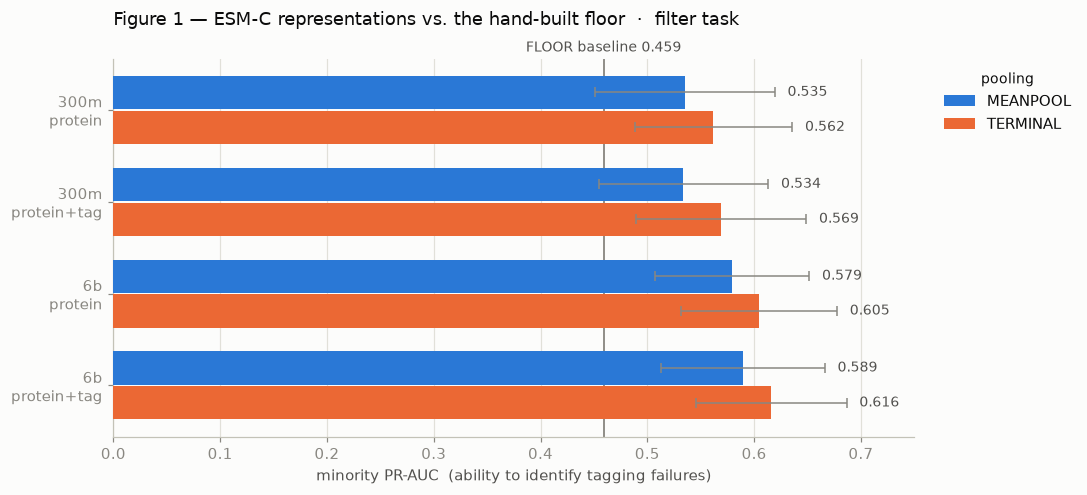

In [5]:
sel = best_per_cell("filter", "pr_auc_minority_mean")
emb = sel[sel["cell"] != "baseline"]
cells = [c for c in CELL_ORDER if c != "baseline"]
labels = ["300m\nprotein", "300m\nprotein+tag", "6b\nprotein", "6b\nprotein+tag"]

floor = sel[(sel["cell"] == "baseline") & (sel["feature_set"] == "FLOOR")]
floor_v = float(floor["pr_auc_minority_mean"].iloc[0])

fig, ax = plt.subplots(figsize=(10, 4.6))
y, h = np.arange(len(cells)), 0.36

for i, (fs, color) in enumerate([("MEANPOOL", BLUE), ("TERMINAL", ORANGE)]):
    vals, errs = [], []
    for c in cells:
        r = emb[(emb["cell"] == c) & (emb["feature_set"] == fs)]
        vals.append(float(r["pr_auc_minority_mean"].iloc[0]))
        errs.append(float(r["pr_auc_minority_std"].iloc[0]))
    off = (i - 0.5) * (h + 0.02)      # 2px-equivalent gap between adjacent bars
    ax.barh(y + off, vals, height=h, color=color, label=fs, zorder=3)
    ax.errorbar(vals, y + off, xerr=errs, fmt="none", ecolor=MUTED,
                elinewidth=1, capsize=3, zorder=4)
    for yi, v, e in zip(y + off, vals, errs):   # direct labels (relief rule)
        ax.text(v + e + 0.012, yi, f"{v:.3f}", va="center", fontsize=9, color=INK2)

# Reference line labelled just above the axes, so it can never collide with the marks.
tr = blended_transform_factory(ax.transData, ax.transAxes)
ax.axvline(floor_v, color=MUTED, lw=1.2, zorder=2)
ax.text(floor_v, 1.01, f"FLOOR baseline {floor_v:.3f}", transform=tr,
        ha="center", va="bottom", fontsize=9, color=INK2)

ax.set_yticks(y, labels)
ax.set_xlim(0, 0.75)
ax.set_xlabel("minority PR-AUC  (ability to identify tagging failures)")
ax.set_title("Figure 1 — ESM-C representations vs. the hand-built floor  ·  filter task",
             fontsize=12, pad=22, loc="left")
ax.invert_yaxis()
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="pooling", title_fontsize=9)
plt.tight_layout(); plt.show()

### Figure 2 — The same comparison for the terminus task

**What is different here.** This task asks: given that tagging works, does the tag
belong on the N- or the C-terminus? Only the 1,310 successful rows are used, and the
classes are nearly balanced (913 N vs 844 C among all rows; base rate 0.559 among
successes), so plain PR-AUC is readable directly.

**Why only two representations.** The `protein+tag` construct cells are deliberately
excluded from this task. The construct sequence *has the tag physically placed at one
terminus* — feeding it in would hand the model the answer. `configurations()` in
`run_grid.py` skips them with the comment "tag placement would encode the label."
That is why this task has 20 rows and the `filter` task has 44.

**What to notice.** The gap between `MEANPOOL` and `TERMINAL` is much wider here than
in figure 1. That is the expected result and it is the cleanest signal in the whole
grid: "which end should the tag go on" is almost entirely a question about the ends,
so a feature set that looks at the ends wins. A whole-protein average dilutes a
25-residue signal peptide by twentyfold.

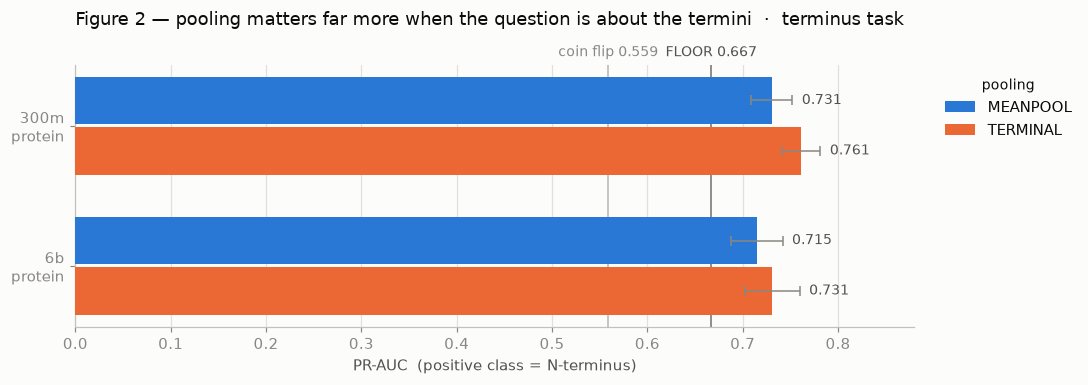

In [6]:
sel = best_per_cell("terminus", "pr_auc_mean")
emb = sel[sel["cell"] != "baseline"]
cells = ["OpenCell/protein/300m", "OpenCell/protein/6b"]
labels = ["300m\nprotein", "6b\nprotein"]

floor = sel[sel["cell"] == "baseline"]
floor_v = float(floor["pr_auc_mean"].iloc[0])
base_rate = 0.559

fig, ax = plt.subplots(figsize=(10, 3.6))
y, h = np.arange(len(cells)), 0.34

for i, (fs, color) in enumerate([("MEANPOOL", BLUE), ("TERMINAL", ORANGE)]):
    vals, errs = [], []
    for c in cells:
        r = emb[(emb["cell"] == c) & (emb["feature_set"] == fs)]
        vals.append(float(r["pr_auc_mean"].iloc[0]))
        errs.append(float(r["pr_auc_std"].iloc[0]))
    off = (i - 0.5) * (h + 0.02)
    ax.barh(y + off, vals, height=h, color=color, label=fs, zorder=3)
    ax.errorbar(vals, y + off, xerr=errs, fmt="none", ecolor=MUTED,
                elinewidth=1, capsize=3, zorder=4)
    for yi, v, e in zip(y + off, vals, errs):
        ax.text(v + e + 0.010, yi, f"{v:.3f}", va="center", fontsize=9, color=INK2)

tr = blended_transform_factory(ax.transData, ax.transAxes)
ax.axvline(base_rate, color=AXIS, lw=1.2, zorder=2)
ax.text(base_rate, 1.02, f"coin flip {base_rate:.3f}", transform=tr,
        ha="center", va="bottom", fontsize=9, color=MUTED)
ax.axvline(floor_v, color=MUTED, lw=1.2, zorder=2)
ax.text(floor_v, 1.02, f"FLOOR {floor_v:.3f}", transform=tr,
        ha="center", va="bottom", fontsize=9, color=INK2)

ax.set_yticks(y, labels)
ax.set_xlim(0, 0.88)
ax.set_xlabel("PR-AUC  (positive class = N-terminus)")
ax.set_title("Figure 2 — pooling matters far more when the question is about the termini  ·  terminus task",
             fontsize=12, pad=26, loc="left")
ax.invert_yaxis()
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="pooling", title_fontsize=9)
plt.tight_layout(); plt.show()

### Figure 3 — The scale axis: is the 6B model worth it over the 300M?

**The form.** This is a *dumbbell* chart — the right tool for "before → after, per
item." Each row is one held-fixed configuration; the light dot is that configuration
run on `300m` embeddings, the dark dot is the identical configuration on `6b`. The
connecting line is the effect of scaling the model up. Everything else — task,
pooling, fold assignment — is held constant along each row, which is the entire point
of running the sweep as a factorial.

**How to read it.** A line pointing right means the bigger model helped. The number
at the right end is the delta. Compare those deltas against the fold-to-fold standard
deviations you saw in figures 1 and 2 (typically 0.013–0.030) before reading much
into any single row.

**The practical question this answers.** The 6B model produces 2,560-dimensional
embeddings against the 300M model's 960, costs substantially more to run, and — as
figure 6 shows — makes the downstream fits roughly 3× slower. This chart is how you
decide whether that is buying you anything.

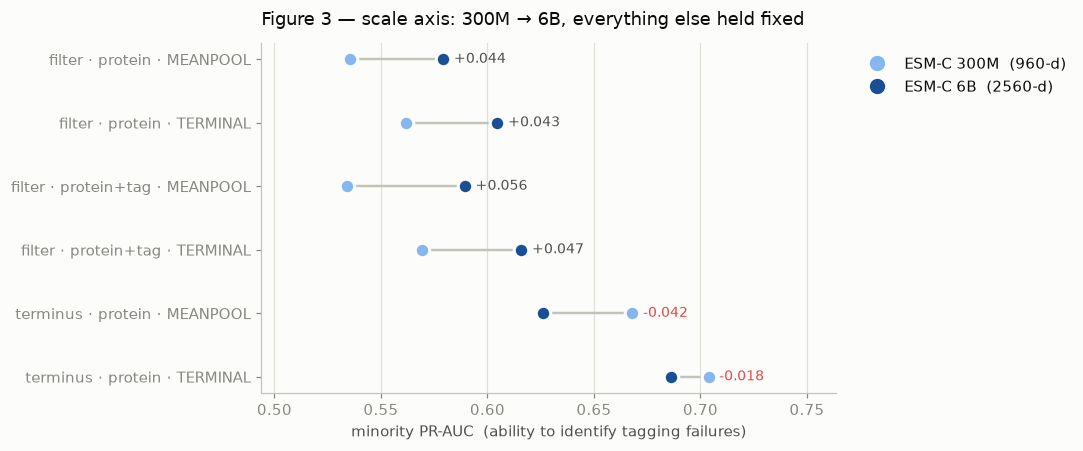

In [7]:
XLAB = "minority PR-AUC  (ability to identify tagging failures)"


def dumbbell(ax, rows, lo_lab, hi_lab, title, xlabel=XLAB):
    """rows: list of (row_label, low_value, high_value)."""
    y = np.arange(len(rows))
    for i, (_, lo, hi) in enumerate(rows):
        ax.plot([lo, hi], [i, i], color=AXIS, lw=1.6, zorder=2,
                solid_capstyle="round")
        ax.scatter([lo], [i], s=90, color=BLUE_LT, zorder=3,
                   edgecolors=SURF, linewidths=2)          # 2px surface ring
        ax.scatter([hi], [i], s=90, color=BLUE_DK, zorder=4,
                   edgecolors=SURF, linewidths=2)
        d = hi - lo
        ax.text(max(lo, hi) + 0.005, i, f"{d:+.3f}", va="center",
                fontsize=9, color=INK2 if d > 0 else RED)
    ax.set_yticks(y, [r[0] for r in rows])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=12, pad=12, loc="left")
    ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
    # Legend outside the plot area — dumbbell rows can reach any x position.
    ax.legend(handles=[
        Line2D([], [], marker="o", ls="", ms=9, color=BLUE_LT, label=lo_lab),
        Line2D([], [], marker="o", ls="", ms=9, color=BLUE_DK, label=hi_lab),
    ], loc="upper left", bbox_to_anchor=(1.02, 1))


def lookup(task, cell, fs, metric):
    r = raw[(raw["task"] == task) & (raw["cell"] == cell) & (raw["feature_set"] == fs)]
    return float(r[metric].max())          # best variant at that cell

M = "pr_auc_minority_mean"
rows = []
for task in ["filter", "terminus"]:
    fams = ["protein", "protein+tag"] if task == "filter" else ["protein"]
    for fam in fams:
        for fs in ["MEANPOOL", "TERMINAL"]:
            rows.append((f"{task} · {fam} · {fs}",
                         lookup(task, f"OpenCell/{fam}/300m", fs, M),
                         lookup(task, f"OpenCell/{fam}/6b", fs, M)))

fig, ax = plt.subplots(figsize=(10, 4.2))
dumbbell(ax, rows, "ESM-C 300M  (960-d)", "ESM-C 6B  (2560-d)",
         "Figure 3 — scale axis: 300M → 6B, everything else held fixed")
lo = min(min(r[1], r[2]) for r in rows)
hi = max(max(r[1], r[2]) for r in rows)
ax.set_xlim(lo - 0.04, hi + 0.06)
plt.tight_layout(); plt.show()

### Figure 4 — The tag axis: does showing the model the actual fusion construct help?

**The comparison.** Same dumbbell form, different axis. The light dot embeds the
**bare protein sequence**; the dark dot embeds the **full fusion construct** — the
protein with the mNG2(11) tag and linker spliced onto the real tagged terminus. The
construct cells also get an extra feature block, `junction_25`: the embedding
averaged over ±25 residues around the splice point, where the tag meets the protein.

**Why this is the interesting axis.** Intuitively the construct should win — it is
literally the molecule that succeeded or failed, whereas the bare protein is missing
the tag entirely. Whether the model actually extracts anything from the junction is
an empirical question, and it is the one this chart settles.

**`filter` task only.** As in figure 2, the construct representation is unusable for
the terminus task because the tag's position *is* the label.

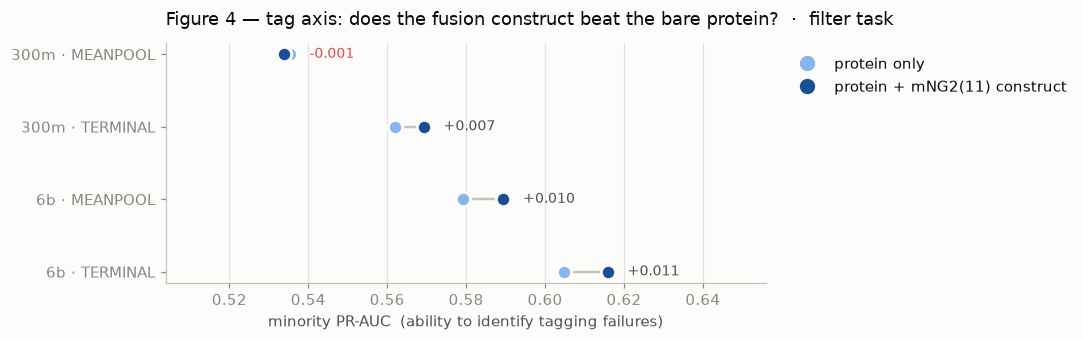

In [8]:
rows = []
for model in ["300m", "6b"]:
    for fs in ["MEANPOOL", "TERMINAL"]:
        rows.append((f"{model} · {fs}",
                     lookup("filter", f"OpenCell/protein/{model}", fs, M),
                     lookup("filter", f"OpenCell/protein+tag/{model}", fs, M)))

fig, ax = plt.subplots(figsize=(10, 3.2))
dumbbell(ax, rows, "protein only", "protein + mNG2(11) construct",
         "Figure 4 — tag axis: does the fusion construct beat the bare protein?  ·  filter task")
lo = min(min(r[1], r[2]) for r in rows)
hi = max(max(r[1], r[2]) for r in rows)
ax.set_xlim(lo - 0.03, hi + 0.04)
plt.tight_layout(); plt.show()

### Figure 5 — Did class weighting help? All 32 paired configurations

**What the sweep did.** Class imbalance is usually "fixed" by resampling —
SMOTE, undersampling, and so on. This grid deliberately does none of that. The only
imbalance knob is `class_weight="balanced"` for logistic regression and
`scale_pos_weight` for XGBoost, and **both settings are always run**, so the knob can
be judged on cross-validated evidence rather than on folklore.

**How to read it.** Every bar is one matched pair: the same task, cell, pooling, and
classifier, run weighted minus run unweighted. Bars to the right (blue) mean
weighting helped; bars to the left (red) mean it hurt. The chart is centered on zero
because the question is directional — this is a *diverging* encoding, not a ranking.

**What to conclude.** Read the scale on the x-axis before reading the pattern. If the
deltas are an order of magnitude smaller than the fold-to-fold noise (±0.013–0.030),
then the honest answer is that the knob does essentially nothing on this dataset, and
the extra 32 fits bought you the confidence to say so. Threshold selection from the
PR curve is already handling the imbalance.

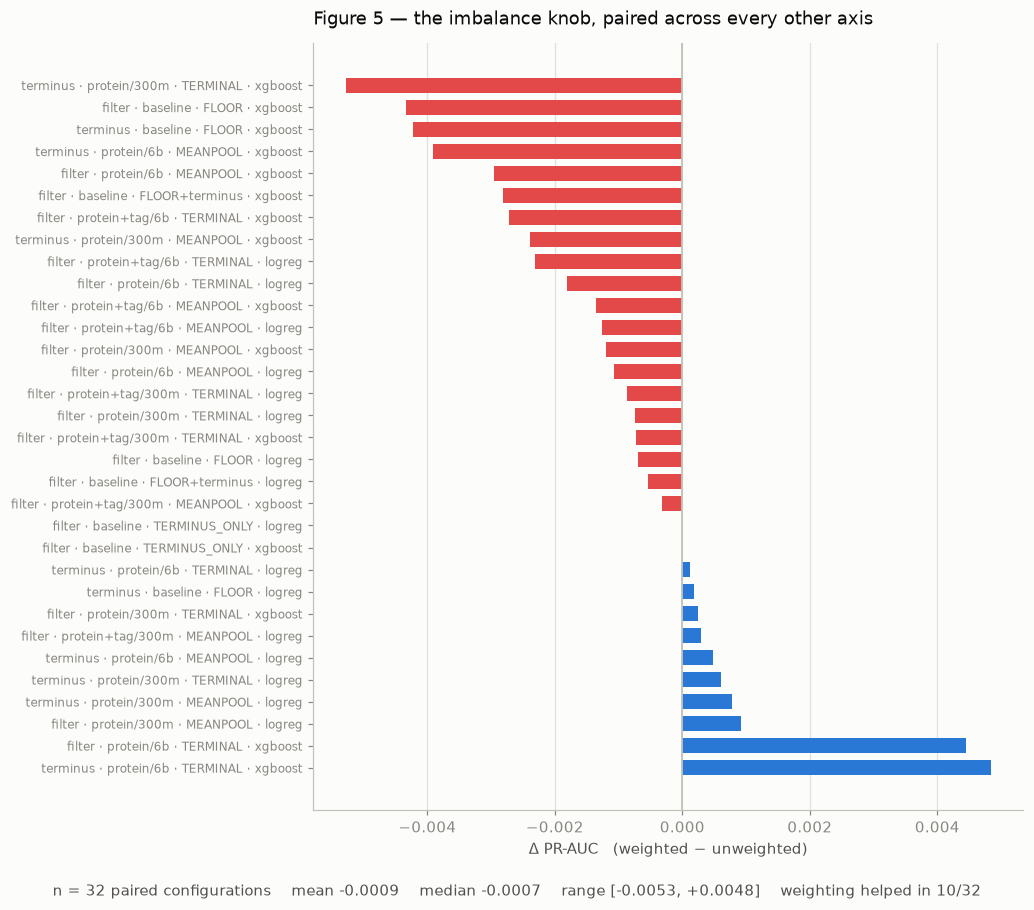

In [9]:
keys = ["task", "cell", "feature_set", "classifier"]
piv = raw.pivot_table(index=keys, columns="weighted", values="pr_auc_mean").dropna()
delta = (piv[True] - piv[False]).sort_values()

names = [f"{t} · {c.replace('OpenCell/', '')} · {fs} · {clf}"
         for t, c, fs, clf in delta.index]
colors = [BLUE if v >= 0 else RED for v in delta.values]

fig, ax = plt.subplots(figsize=(9.5, 8))
ax.barh(np.arange(len(delta)), delta.values, height=0.68, color=colors, zorder=3)
ax.axvline(0, color=AXIS, lw=1.2, zorder=4)
ax.set_yticks(np.arange(len(delta)), names, fontsize=8)
ax.set_xlabel("Δ PR-AUC   (weighted − unweighted)")
ax.set_title("Figure 5 — the imbalance knob, paired across every other axis",
             fontsize=12, pad=12, loc="left")
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.invert_yaxis()

plt.tight_layout()
# Summary sits below the axis label, never on top of a bar.
lo, hi = delta.min(), delta.max()
fig.text(0.5, -0.012,
         f"n = {len(delta)} paired configurations    mean {delta.mean():+.4f}    "
         f"median {delta.median():+.4f}    range [{lo:+.4f}, {hi:+.4f}]    "
         f"weighting helped in {(delta > 0).sum()}/{len(delta)}",
         ha="center", va="top", fontsize=9.5, color=INK2)
plt.show()

### Figure 6 — What each configuration cost to fit

**Why this chart exists.** The sweep took about half an hour of wall clock, and that
time was distributed extremely unevenly. This shows where it went, on log–log axes
because the spread covers four orders of magnitude in feature count.

**How to read it.** Each point is one configuration from the raw block: x is
`n_features`, y is `seconds`. Blue points are logistic regression, orange are XGBoost.

**The two things to notice.**

1. **XGBoost scales almost linearly with feature count** — about 0.0155 seconds per
   feature above ~1,000. With `tree_method="hist"`, every node build costs
   O(rows × features) to accumulate gradient histograms, and that cost is paid for
   every candidate feature whether or not it wins a split. Widen the matrix, pay
   proportionally.
2. **Logistic regression barely moves at all** — roughly 1.9s at 21 features and 4.6s
   at 3,840, across a 180× increase. Each `logreg` configuration runs 80 LBFGS fits
   (5 outer folds × [5 `C` values × 3 inner folds + 1 refit]), and at n≈1,400 rows
   each fit is trivial. What you are timing is the joblib process-pool spin-up, not
   the optimization.

The practical consequence: the three baseline configurations finished in
1–6 seconds each, while `6b · protein+tag · TERMINAL` with XGBoost — 10,240
features — took about 230 seconds per variant. Two configurations accounted for
more of the runtime than the other sixty-two combined.

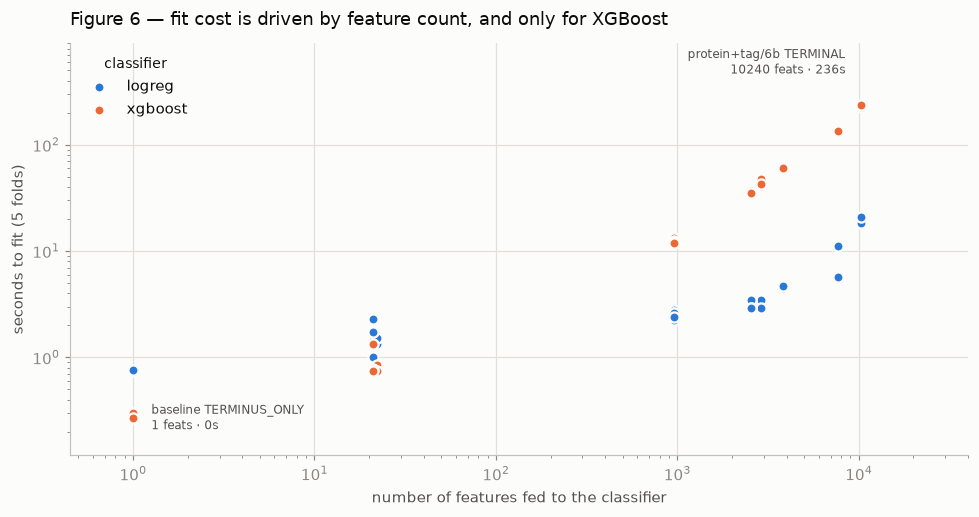

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.8))

for clf, color in [("logreg", BLUE), ("xgboost", ORANGE)]:
    s = raw[raw["classifier"] == clf]
    ax.scatter(s["n_features"], s["seconds"], s=44, color=color, label=clf,
               zorder=3, edgecolors=SURF, linewidths=1.5)   # 2px surface ring

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.45, 4e4); ax.set_ylim(0.12, 900)
ax.set_xlabel("number of features fed to the classifier")
ax.set_ylabel("seconds to fit (5 folds)")
ax.set_title("Figure 6 — fit cost is driven by feature count, and only for XGBoost",
             fontsize=12, pad=12, loc="left")
ax.grid(True, which="major", zorder=0); ax.set_axisbelow(True)
ax.legend(loc="upper left", title="classifier", title_fontsize=9)

# Selective direct labels: only the single cheapest and single most expensive fit.
# The expensive one is labelled up-and-left so it clears both its own mark and its neighbour.
for _, r in pd.concat([raw.nsmallest(1, "seconds"), raw.nlargest(1, "seconds")]).iterrows():
    right = r["n_features"] > 500
    ax.annotate(f"{r['cell'].replace('OpenCell/', '')} {r['feature_set']}\n"
                f"{int(r['n_features'])} feats · {r['seconds']:.0f}s",
                (r["n_features"], r["seconds"]), textcoords="offset points",
                xytext=(-10, 18) if right else (12, 0),
                ha="right" if right else "left",
                va="bottom" if right else "center",
                fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

### Figure 7 — Precision–recall curves from the held-out predictions

**A different source file.** Every figure so far read `master_results.csv`, which
stores *aggregated* metrics. This one reads
`/workspace/fluoresceAnything/results/oof_predictions.csv` — the raw per-row
out-of-fold predicted probabilities, roughly 15 MB, one block per configuration.
"Out-of-fold" means every prediction was made by a model that never saw that gene
during training, so pooling them across folds gives an honest curve.

**How to read a PR curve.** The x-axis is recall (of all true successes, what
fraction did you retrieve) and the y-axis is precision (of everything you flagged as
a success, what fraction really was). You want the curve pushed toward the top right.
The flat grey line at 0.746 is the base rate — where a coin-flip classifier sits, and
the only meaningful floor on an imbalanced problem.

**The emphasis choice.** The baseline is drawn in grey as context; the two ESM-C
cells carry the color. That is deliberate — the story is the gap between the
representations, not a three-way race between equals.

**Where the difference actually lives.** The curves are nearly indistinguishable at
low recall — both approaches confidently identify the easy successes. They separate
in the high-recall region on the right, which is exactly the regime you care about
if the goal is to greenlight as much of the library as possible without wasting
cloning effort on doomed targets.

/workspace/fluoresceAnything/results/oof_predictions.csv
103,508 rows · 64 configurations

FLOOR baseline (21 features)     <- filter|baseline|FLOOR+terminus|logreg|u


ESM-C 300M, protein              <- filter|OpenCell/protein/300m|TERMINAL|logreg|u
ESM-C 6B, protein+tag            <- filter|OpenCell/protein+tag/6b|TERMINAL|logreg|u


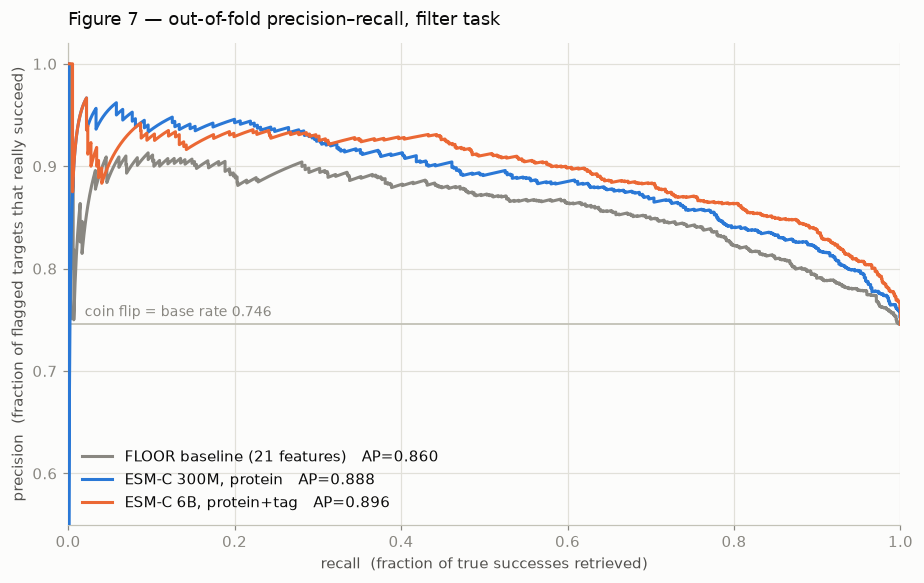

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score

oof = pd.read_csv(OOF)
print(f"{OOF}\n{len(oof):,} rows · {oof['config_id'].nunique()} configurations\n")

f = oof[oof["task"] == "filter"]
base_rate = f.groupby("config_id")["y"].mean().iloc[0]

# Pick the best-scoring config within each representation family.
def best_config(cell):
    sub = f[f["cell"] == cell]
    scores = {cid: average_precision_score(1 - g["y"], 1 - g["p"])
              for cid, g in sub.groupby("config_id")}
    return max(scores, key=scores.get)

picks = [("baseline",                MUTED,  "FLOOR baseline (21 features)"),
         ("OpenCell/protein/300m",   BLUE,   "ESM-C 300M, protein"),
         ("OpenCell/protein+tag/6b", ORANGE, "ESM-C 6B, protein+tag")]

fig, ax = plt.subplots(figsize=(8.5, 5.4))
for cell, color, label in picks:
    cid = best_config(cell)
    g = f[f["config_id"] == cid]
    prec, rec, _ = precision_recall_curve(g["y"], g["p"])
    ap = average_precision_score(g["y"], g["p"])
    ax.plot(rec, prec, color=color, lw=2, zorder=3, label=f"{label}   AP={ap:.3f}")
    print(f"{label:32s} <- {cid}")

ax.axhline(base_rate, color=AXIS, lw=1.2, zorder=2)
ax.text(0.02, base_rate + 0.008, f"coin flip = base rate {base_rate:.3f}",
        fontsize=9, color=MUTED)

ax.set_xlabel("recall  (fraction of true successes retrieved)")
ax.set_ylabel("precision  (fraction of flagged targets that really succeed)")
ax.set_ylim(0.55, 1.02); ax.set_xlim(0, 1)
ax.set_title("Figure 7 — out-of-fold precision–recall, filter task",
             fontsize=12, pad=12, loc="left")
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

---

## 6. Reproducing this

```bash
cd /workspace/fluoresceAnything

# 1. build the modeling table from the OpenCell supplement + UniProt
python src/data_cleaning/fetch_sequences.py
python src/tags/build_constructs.py          # -> data/modeling_table.csv

# 2. embed (one pass per cell; GPU, writes pooled vectors only)
python src/embed/esmc_embed.py --model 300m --seqtype protein
python src/embed/esmc_embed.py --model 300m --seqtype construct
python src/embed/esmc_embed.py --model 6b   --seqtype protein
python src/embed/esmc_embed.py --model 6b   --seqtype construct

# 3. run the 64-configuration sweep (~30 min, CPU-bound)
python src/modeling/run_grid.py              # -> results/master_results.csv
                                             #    results/oof_predictions.csv

# 4. markdown summary tables for the report
python src/modeling/summarize.py
```

**Two knobs worth knowing.** `run_grid.py --no-tune` skips the inner `C` search for a
fast smoke test, and `--tasks filter` runs a single task. The fold files in
`results/` are cached and reused; `data.py` asserts they match the current table
rather than silently using a stale split, so **delete `results/folds_*.csv` if the
modeling table changes**.

**One unused lever.** `esmc_embed.py` caches `WINDOWS = [25, 50]`, but the modeling
code only ever reads the 25-residue blocks (`K_TERMINAL = 25` in `data.py`). A
50-residue `TERMINAL` variant is already sitting in the `.npz` caches and would cost
nothing to evaluate — no re-embedding required.